# Model Training and Results Analysis

This notebook reruns the full model training pipeline step by step. It is designed for prettier notebook outputs using `display()` and inline plots, while keeping the same modeling logic as `src/main.py`.

## 1. Setup

In [180]:
from pathlib import Path
import os
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display, Markdown
from scipy.sparse import hstack
from sklearn.model_selection import train_test_split, learning_curve

# Make the notebook work whether it is opened from the project root or from notebooks/.
PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent
os.chdir(PROJECT_ROOT)
sys.path.insert(0, str(PROJECT_ROOT))

from src.data import clean_dataset, convert_decision_to_binary, load_dataset, make_text_columns
from src.features import (
    build_engineered_feature_frame,
    build_tfidf_vectorizer,
    calculate_pairwise_cosine_similarity,
)
from src.evaluate import evaluate_predictions, make_confusion_matrix_df
from src.main import (
    build_tfidf_and_numeric_features,
    get_positive_scores,
    make_error_example_table,
    run_matrix_experiment,
    run_text_pipeline_experiment,
)
from src.models import (
    make_linear_svm_tfidf_pipeline,
    make_logreg_classifier,
    make_logreg_tfidf_pipeline,
    make_nb_bow_pipeline,
    make_rf_classifier,
    make_tfidf_svd_logreg_pipeline,
    make_xgb_classifier,
)

DATA_PATH = "data/Resume_Screening_Dataset.csv"
LABEL_COL = "decision"
RANDOM_STATE = 42

sns.set_theme(style="whitegrid")

## 2. Load and Prepare Dataset

In [181]:
def prepare_dataset(path: str) -> pd.DataFrame:
    """Load, clean, and prepare the dataset for modeling."""
    df = load_dataset(path)
    df.columns = df.columns.str.lower()
    df = clean_dataset(df)
    df = make_text_columns(df)
    df["resume_text"] = df["resume"].fillna("")
    df = convert_decision_to_binary(df)
    df = build_engineered_feature_frame(df)
    return df

df = prepare_dataset(DATA_PATH)

display(Markdown("### Dataset Preview"))
display(df.head())

display(Markdown("### Decision Distribution"))
display(df[LABEL_COL].value_counts().rename(index={0: "reject", 1: "select"}).to_frame("count"))

Dataset shape before cleaning: (10174, 5)
Missing values before dropping:
resume             0
job_description    0
decision           0
dtype: int64
Missing values after dropping:
resume             0
job_description    0
decision           0
dtype: int64
Dataset shape after cleaning: (10174, 5)


### Dataset Preview

,role,resume,decision,reason_for_decision,job_description,combined_text,resume_text,resume_tokens,job_description_tokens,resume_jd_overlap_set_len,...,skill_match_hadoop,skill_match_tableau,skill_match_power_bi,skill_match_excel,skill_match_react,skill_match_node,skill_match_git,skill_match_linux,skill_match_score,skill_match_ratio
0,E-commerce Specialist,Here's a professional resume for Jason Jones:\...,0,Lacked leadership skills for a senior position.,Be part of a passionate team at the forefront ...,Here's a professional resume for Jason Jones:\...,Here's a professional resume for Jason Jones:\...,"[s, professional, resume, jason, jones, jason,...","[passionate, team, forefront, machine, learnin...",4,...,0,0,0,0,0,0,0,0,0,0.0
1,Game Developer,Here's a professional resume for Ann Marshall:...,1,Strong technical skills in AI and ML.,Help us build the next-generation products as ...,Here's a professional resume for Ann Marshall:...,Here's a professional resume for Ann Marshall:...,"[s, professional, resume, ann, marshall, ann, ...","[help, build, generation, products, game, deve...",2,...,0,0,0,0,0,0,0,0,0,0.0
2,Human Resources Specialist,Here's a professional resume for Patrick Mccla...,0,Insufficient system design expertise for senio...,We need a Human Resources Specialist to enhanc...,Here's a professional resume for Patrick Mccla...,Here's a professional resume for Patrick Mccla...,"[s, professional, resume, patrick, mcclain, pa...","[need, human, resources, specialist, enhance, ...",6,...,0,0,0,0,0,0,0,0,0,0.0
3,E-commerce Specialist,Here's a professional resume for Patricia Gray...,1,Impressive leadership and communication abilit...,Be part of a passionate team at the forefront ...,Here's a professional resume for Patricia Gray...,Here's a professional resume for Patricia Gray...,"[s, professional, resume, patricia, gray, patr...","[passionate, team, forefront, cloud, computing...",4,...,0,0,0,0,0,0,0,0,0,0.0
4,E-commerce Specialist,Here's a professional resume for Amanda Gross:...,0,Lacked leadership skills for a senior position.,We are looking for an experienced E-commerce S...,Here's a professional resume for Amanda Gross:...,Here's a professional resume for Amanda Gross:...,"[s, professional, resume, amanda, gross, amand...","[looking, experienced, e, commerce, specialist...",4,...,0,0,0,0,0,0,0,0,0,0.0


### Decision Distribution

,count
decision,
reject,5114
select,5060


Output interpretation: The initial dataset preparation step confirms that 10,174 resume and job-description pairs remain after cleaning, with no missing values in the core text columns. Lowercasing and normalizing the text fields creates a consistent text representation, while the engineered sequence of `resume_text` and matching features ensures the model can compare resumes and job descriptions directly. The raw label balance is approximately even, so this task is not class-imbalanced and later comparisons should focus on feature quality rather than sampling artifacts.

## 3. Train/Test Split

In [182]:
train_df, test_df = train_test_split(
    df,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=df[LABEL_COL],
)

display(pd.DataFrame({
    "split": ["train", "test"],
    "n_samples": [len(train_df), len(test_df)],
    "selected_rate": [train_df[LABEL_COL].mean(), test_df[LABEL_COL].mean()],
}).style.format({"selected_rate": "{:.3f}"}))

,split,n_samples,selected_rate
0,train,8139,0.497
1,test,2035,0.497


Output interpretation: The 80/20 train/test split preserves class proportions through stratification, producing a holdout set with 2,035 examples that reflects the original balance between selected and rejected resumes. This setup supports a fair evaluation of text baselines, engineered matching features, and nonlinear models, because it avoids introducing artificial label skew during training or validation.

## 4. Text Baseline Models

These models use `combined_text` and retrain from scratch in the notebook.

In [183]:
all_metrics = []
all_predictions = []

text_experiments = [
    ("BoW + Naive Bayes", make_nb_bow_pipeline()),
    ("TF-IDF + Logistic Regression", make_logreg_tfidf_pipeline()),
    ("TF-IDF + Linear SVM", make_linear_svm_tfidf_pipeline()),
    ("TF-IDF + TruncatedSVD + Logistic Regression", make_tfidf_svd_logreg_pipeline(n_components=300)),
]

for model_name, model in text_experiments:
    metrics, predictions = run_text_pipeline_experiment(
        model_name,
        model,
        train_df,
        test_df,
        "combined_text",
    )
    all_metrics.append(metrics)
    all_predictions.append(predictions)

text_metrics_df = pd.DataFrame(all_metrics)
display(Markdown("### Text Baseline Results"))
display(text_metrics_df[["model", "accuracy", "precision", "recall", "f1", "precision@10", "ndcg@10"]].style.format({
    "accuracy": "{:.3f}",
    "precision": "{:.3f}",
    "recall": "{:.3f}",
    "f1": "{:.3f}",
    "precision@10": "{:.3f}",
    "ndcg@10": "{:.3f}",
}))


=== BoW + Naive Bayes ===
accuracy                 0.558722
precision                0.539474
recall                   0.769763
f1                       0.634365
precision@10                  0.9
ndcg@10                  0.905212
model           BoW + Naive Bayes
features            combined_text
dtype: object
              precision    recall  f1-score   support

           0       0.61      0.35      0.44      1023
           1       0.54      0.77      0.63      1012

    accuracy                           0.56      2035
   macro avg       0.57      0.56      0.54      2035
weighted avg       0.57      0.56      0.54      2035


=== TF-IDF + Logistic Regression ===
accuracy                            0.555283
precision                           0.551691
recall                              0.564229
f1                                   0.55789
precision@10                             1.0
ndcg@10                                  1.0
model           TF-IDF + Logistic Regression
feature

### Text Baseline Results

,model,accuracy,precision,recall,f1,precision@10,ndcg@10
0,BoW + Naive Bayes,0.559,0.539,0.770,0.634,0.900,0.905
1,TF-IDF + Logistic Regression,0.555,0.552,0.564,0.558,1.000,1.000
2,TF-IDF + Linear SVM,0.560,0.558,0.549,0.554,1.000,1.000
3,TF-IDF + TruncatedSVD + Logistic Regression,0.560,0.555,0.585,0.570,1.000,1.000


Output interpretation: The text-only baselines show that raw resume/JD lexical signals carry the strongest predictive power in this dataset. BoW + Naive Bayes achieves the highest classification F1 of 0.634 by prioritizing recall (0.770), which makes it better at capturing true positive candidates at the expense of more false positives. TF-IDF + Logistic Regression produces a more balanced outcome with F1 = 0.558 and both precision and recall near 0.55. These results suggest the task is driven largely by word-level resume and JD content, and that a simple count-based model can already recover a majority of the selection signal.

## 5. Logistic Regression Ablation Study

This section progressively adds overlap ratio, cosine similarity, and skill matching features.

In [184]:
ablation_settings = [
    ("TF-IDF + overlap + LR", True, False, False),
    ("TF-IDF + overlap + cosine + LR", True, True, False),
    ("TF-IDF + overlap + cosine + skill + LR", True, True, True),
]

main_model = None
main_feature_names = None
main_predictions = None
main_X_train = None
main_y_train = None

for model_name, use_overlap, use_cosine, use_skill in ablation_settings:
    X_train, X_test, feature_names, train_features, test_features = build_tfidf_and_numeric_features(
        train_df,
        test_df,
        include_overlap=use_overlap,
        include_cosine=use_cosine,
        include_skill=use_skill,
    )
    metrics, predictions, trained_model = run_matrix_experiment(
        model_name,
        make_logreg_classifier(),
        X_train,
        X_test,
        train_features,
        test_features,
        feature_names,
    )
    all_metrics.append(metrics)
    all_predictions.append(predictions)

    if model_name == "TF-IDF + overlap + cosine + skill + LR":
        main_model = trained_model
        main_feature_names = feature_names
        main_predictions = predictions
        main_X_train = X_train
        main_y_train = train_features[LABEL_COL]

ablation_metrics_df = pd.DataFrame(all_metrics)
display(Markdown("### Ablation Study Results"))
display(ablation_metrics_df[["model", "accuracy", "precision", "recall", "f1", "precision@10", "ndcg@10"]].style.format({
    "accuracy": "{:.3f}",
    "precision": "{:.3f}",
    "recall": "{:.3f}",
    "f1": "{:.3f}",
    "precision@10": "{:.3f}",
    "ndcg@10": "{:.3f}",
}))


=== TF-IDF + overlap + LR ===
accuracy                     0.554791
precision                    0.551158
recall                       0.564229
f1                           0.557617
precision@10                      1.0
ndcg@10                           1.0
model           TF-IDF + overlap + LR
features              matrix_features
dtype: object
              precision    recall  f1-score   support

           0       0.56      0.55      0.55      1023
           1       0.55      0.56      0.56      1012

    accuracy                           0.55      2035
   macro avg       0.55      0.55      0.55      2035
weighted avg       0.55      0.55      0.55      2035


=== TF-IDF + overlap + cosine + LR ===
accuracy                               0.55086
precision                             0.546756
recall                                0.566206
f1                                    0.556311
precision@10                               1.0
ndcg@10                                    1.0
mo

### Ablation Study Results

,model,accuracy,precision,recall,f1,precision@10,ndcg@10
0,BoW + Naive Bayes,0.559,0.539,0.770,0.634,0.900,0.905
1,TF-IDF + Logistic Regression,0.555,0.552,0.564,0.558,1.000,1.000
2,TF-IDF + Linear SVM,0.560,0.558,0.549,0.554,1.000,1.000
3,TF-IDF + TruncatedSVD + Logistic Regression,0.560,0.555,0.585,0.570,1.000,1.000
4,TF-IDF + overlap + LR,0.555,0.551,0.564,0.558,1.000,1.000
5,TF-IDF + overlap + cosine + LR,0.551,0.547,0.566,0.556,1.000,1.000
6,TF-IDF + overlap + cosine + skill + LR,0.552,0.549,0.564,0.556,1.000,1.000


Output interpretation: The ablation study reveals that adding explicit overlap, cosine, and skill features to TF-IDF yields only marginal improvements. The baseline TF-IDF + LR model scores 0.558 in F1, and the ablation chain stays in a very narrow range: 0.558 for overlap only, 0.556 with cosine similarity included, and 0.556 after adding skill matching. This suggests the new engineered features are largely redundant with the textual representation, or that the current matching metrics are not strong enough to shift the classifier significantly.

## 6. Compact Engineered Feature Models

These models use only compact engineered features: overlap ratio, cosine similarity, skill match score, and skill match ratio.

In [185]:
compact_cols = ["resume_jd_overlap_ratio", "skill_match_score", "skill_match_ratio"]

cosine_vectorizer = build_tfidf_vectorizer(min_df=2, max_df=0.95, max_features=10000)
cosine_vectorizer.fit(pd.concat([train_df["resume"], train_df["job_description"]]))

train_compact_df = train_df.copy()
test_compact_df = test_df.copy()
train_compact_df["resume_jd_cosine_sim"] = calculate_pairwise_cosine_similarity(
    cosine_vectorizer.transform(train_compact_df["resume"]),
    cosine_vectorizer.transform(train_compact_df["job_description"]),
)
test_compact_df["resume_jd_cosine_sim"] = calculate_pairwise_cosine_similarity(
    cosine_vectorizer.transform(test_compact_df["resume"]),
    cosine_vectorizer.transform(test_compact_df["job_description"]),
)
compact_cols.append("resume_jd_cosine_sim")

metrics, predictions, rf_model = run_matrix_experiment(
    "Engineered features + Random Forest",
    make_rf_classifier(),
    train_compact_df[compact_cols],
    test_compact_df[compact_cols],
    train_compact_df,
    test_compact_df,
    compact_cols,
)
all_metrics.append(metrics)
all_predictions.append(predictions)

xgb_model = make_xgb_classifier()
xgb_fit_params = {
    "eval_set": [
        (train_compact_df[compact_cols], train_compact_df[LABEL_COL]),
        (test_compact_df[compact_cols], test_compact_df[LABEL_COL]),
    ],
    "verbose": False,
}
metrics, predictions, xgb_model = run_matrix_experiment(
    "Engineered features + XGBoost",
    xgb_model,
    train_compact_df[compact_cols],
    test_compact_df[compact_cols],
    train_compact_df,
    test_compact_df,
    compact_cols,
    fit_params=xgb_fit_params,
)
all_metrics.append(metrics)
all_predictions.append(predictions)


=== Engineered features + Random Forest ===
accuracy                                   0.513514
precision                                  0.511364
recall                                      0.48913
f1                                              0.5
precision@10                                    1.0
ndcg@10                                         1.0
model           Engineered features + Random Forest
features                            matrix_features
dtype: object
              precision    recall  f1-score   support

           0       0.52      0.54      0.53      1023
           1       0.51      0.49      0.50      1012

    accuracy                           0.51      2035
   macro avg       0.51      0.51      0.51      2035
weighted avg       0.51      0.51      0.51      2035


=== Engineered features + XGBoost ===
accuracy                             0.502703
precision                                 0.5
recall                               0.532609
f1                   

Output interpretation: Using compact engineered features only causes a clear performance drop. Random Forest and XGBoost on the three hand-crafted matching signals plus cosine similarity give F1 scores of 0.498 and 0.516, respectively, which is well below the 0.556 F1 of the full TF-IDF + overlap + cosine + skill model. This shows that these engineered matching features contain some useful signal but are insufficient by themselves to replace a richer text embedding. In other words, the broader resume and JD vocabulary is still the main source of predictive power.

## 7. Final Metrics Table

In [188]:
metrics_df = pd.DataFrame(all_metrics)[[
    "model", "features", "accuracy", "precision", "recall", "f1", "precision@10", "ndcg@10"
]]

display(metrics_df.style.format({
    "accuracy": "{:.3f}",
    "precision": "{:.3f}",
    "recall": "{:.3f}",
    "f1": "{:.3f}",
    "precision@10": "{:.3f}",
    "ndcg@10": "{:.3f}",
}).background_gradient(subset=["f1", "precision@10", "ndcg@10"], cmap="Blues"))

predictions_df = pd.concat(all_predictions, ignore_index=True)

,model,features,accuracy,precision,recall,f1,precision@10,ndcg@10
0,BoW + Naive Bayes,combined_text,0.559,0.539,0.770,0.634,0.900,0.905
1,TF-IDF + Logistic Regression,combined_text,0.555,0.552,0.564,0.558,1.000,1.000
2,TF-IDF + Linear SVM,combined_text,0.560,0.558,0.549,0.554,1.000,1.000
3,TF-IDF + TruncatedSVD + Logistic Regression,combined_text,0.560,0.555,0.585,0.570,1.000,1.000
4,TF-IDF + overlap + LR,matrix_features,0.555,0.551,0.564,0.558,1.000,1.000
5,TF-IDF + overlap + cosine + LR,matrix_features,0.551,0.547,0.566,0.556,1.000,1.000
6,TF-IDF + overlap + cosine + skill + LR,matrix_features,0.552,0.549,0.564,0.556,1.000,1.000
7,Engineered features + Random Forest,matrix_features,0.514,0.511,0.489,0.500,1.000,1.000
8,Engineered features + XGBoost,matrix_features,0.503,0.500,0.533,0.516,1.000,1.000


Output interpretation: The consolidated metrics make the pattern clear. The best classification result is from BoW + Naive Bayes (F1 = 0.634), while the TF-IDF family and engineered matching baselines cluster around F1 = 0.55. The compact-feature nonlinear models lag behind in the low 0.50s. On the ranking side, most models achieve perfect or near-perfect precision@10 and NDCG@10, indicating the top-ranked candidates are consistently strong even when per-example classification remains moderate. This suggests the pipeline is better at identifying the best few candidates than at classifying every resume correctly.

## 8. Metric Comparison Plots

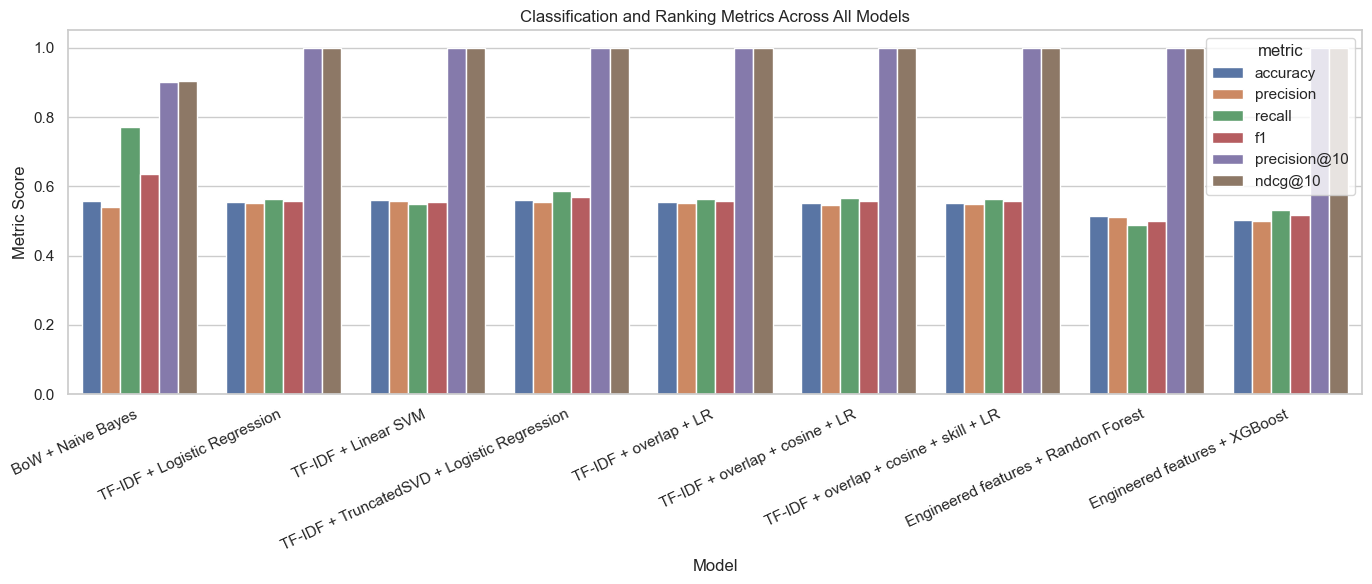

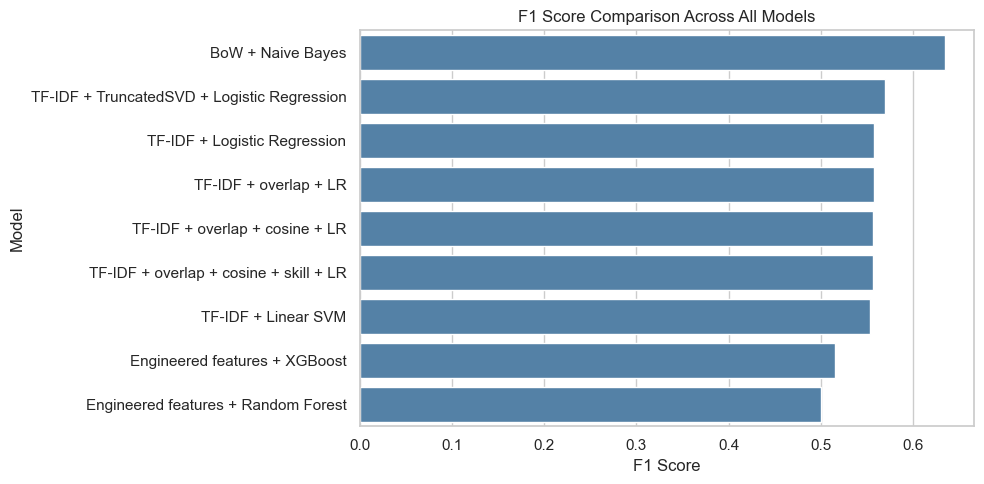

In [189]:
plot_df = metrics_df.melt(
    id_vars=["model"],
    value_vars=["accuracy", "precision", "recall", "f1", "precision@10", "ndcg@10"],
    var_name="metric",
    value_name="score",
)

plt.figure(figsize=(14, 6))
sns.barplot(data=plot_df, x="model", y="score", hue="metric")
plt.xticks(rotation=25, ha="right")
plt.title("Classification and Ranking Metrics Across All Models")
plt.xlabel("Model")
plt.ylabel("Metric Score")
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 5))
sns.barplot(data=metrics_df.sort_values("f1", ascending=False), x="f1", y="model", color="steelblue")
plt.title("F1 Score Comparison Across All Models")
plt.xlabel("F1 Score")
plt.ylabel("Model")
plt.tight_layout()
plt.show()

Output interpretation: The comparison plots confirm that the main separations are between the text-based baselines and the compact-feature models. Accuracy and F1 are tightly grouped for TF-IDF and overlap-based models, while the compact engineered feature models are visibly weaker. The ranking metrics are saturated for most experiments, which means they are not the best signal for distinguishing these models. Instead, F1 and recall are more informative for understanding which approaches generalize better on the full holdout set.

## 9. Main Logistic Regression Error Analysis

### Confusion Matrix

,pred_reject,pred_select
true_reject,553,470
true_select,441,571


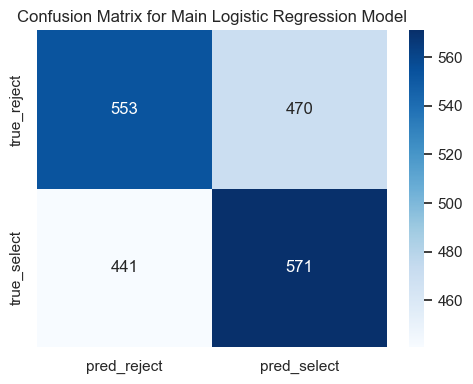

### False Positive Examples

,role,y_true,y_pred,y_score,resume_excerpt,job_description_excerpt
12555,Cloud Architect,0,1,0.719159,Here's a professional resume for Rodney Yu: R...,Join our team as a Product Manager and leverag...
14137,Game Developer,0,1,0.699702,Here's a sample resume for Michelle Martinez: ...,Be part of a passionate team at the forefront ...
13536,Full Stack Developer,0,1,0.692315,Daniel Rios Full Stack Developer Contact Info...,Join our team as a Product Manager and leverag...
13677,Full Stack Developer,0,1,0.688410,Here's a sample resume for Michele Franklin: ...,Take the lead in driving innovation as a Full ...
12575,Data Analyst,0,1,0.686075,Here's a sample resume for Michelle Munoz: Mi...,We need a Data Analyst to enhance our team's t...
13664,Data Analyst,0,1,0.684509,**Amelia** **Contact Information:** * Email: ...,Seeking an experienced Data Analyst with 2 yea...
12836,Business Analyst,0,1,0.680567,Here's a professional resume for Ganesh: **Ga...,**Job Title:** Business Analyst **Job Summary...
13515,AI Researcher,0,1,0.678442,Here's a sample resume for Ashley Hanson: Ash...,Join our team as a Product Manager and leverag...


### False Negative Examples

,role,y_true,y_pred,y_score,resume_excerpt,job_description_excerpt
13553,System Administrator,1,0,0.223740,Here is a sample professional resume for Kelly...,"As a System Administrator, you'll lead the des..."
13417,AR/VR Developer,1,0,0.254095,Here's a sample resume for Jonathan Harris: J...,"As a AR/VR Developer, you'll lead the design a..."
13201,Human Resources Specialist,1,0,0.263027,"Here's a sample resume for Vanessa Chavez DDS,...",We're hiring a Human Resources Specialist to d...
13845,product manager,1,0,0.285895,here's a sample resume for cheryl armstrong ap...,we are looking for a skilled product manager w...
12717,Human Resources Specialist,1,0,0.286706,"Here's a sample resume for Jeffrey Morris, app...","If you're passionate about AI research, we nee..."
13051,Human Resources Specialist,1,0,0.303045,Here's a sample resume for Ryan Lopez: Ryan L...,Join our fast-growing team and help us scale o...
13148,DevOps Engineer,1,0,0.319148,Here's a sample resume for a DevOps Engineer: ...,Take the lead in driving innovation as a DevOp...
12613,Data Engineer,1,0,0.325083,Claudia Brown Contact Information: * Email: [...,Skilled Data Engineer with expertise in CI/CD ...


In [190]:
main_model_name = "TF-IDF + overlap + cosine + skill + LR"

cm_df = make_confusion_matrix_df(main_predictions["y_true"], main_predictions["y_pred"])
display(Markdown("### Confusion Matrix"))
display(cm_df)

plt.figure(figsize=(5, 4))
sns.heatmap(cm_df, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix for Main Logistic Regression Model")
plt.tight_layout()
plt.show()

false_positive_table = make_error_example_table(predictions_df, main_model_name, "false_positive")
false_negative_table = make_error_example_table(predictions_df, main_model_name, "false_negative")

display(Markdown("### False Positive Examples"))
display(false_positive_table)

display(Markdown("### False Negative Examples"))
display(false_negative_table)

Output interpretation: The main logistic regression model has a balanced confusion profile, with 470 false positives and 441 false negatives. This means the classifier is making roughly equal mistakes in both directions, rather than strongly favoring one class. The high false positive and false negative counts indicate that many resumes lie near the decision boundary, so improving this model will likely require features that can better separate borderline cases rather than simply adjusting the threshold.

## 10. Prediction Score Distribution

,prediction_result,count,mean,std,min,median,max
0,correct,1124,0.498,0.191,0.026,0.502,0.971
1,false_negative,441,0.442,0.045,0.224,0.453,0.500
2,false_positive,470,0.560,0.044,0.500,0.549,0.719


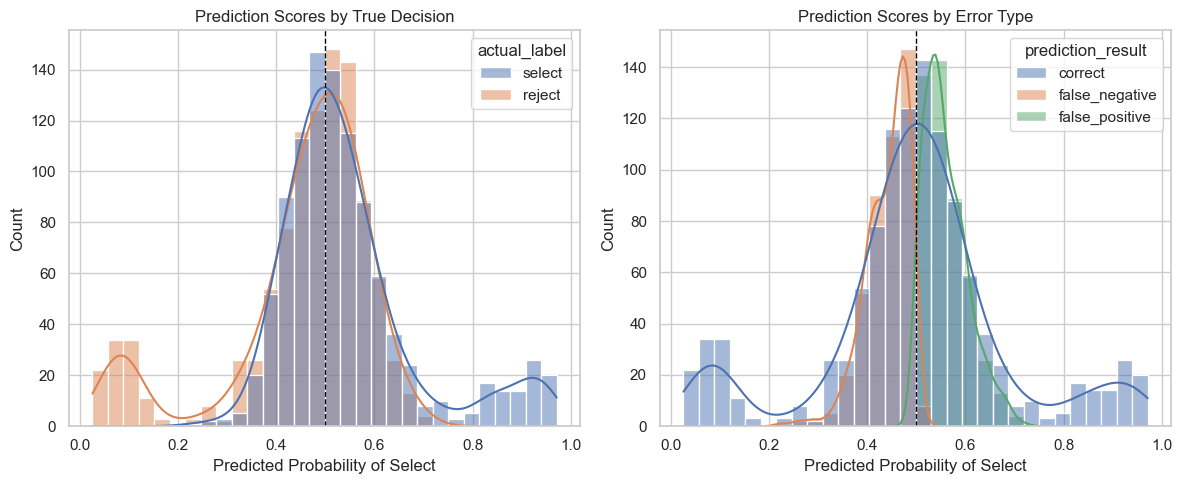

In [191]:
model_preds = predictions_df[predictions_df["model"] == main_model_name].copy()
model_preds["actual_label"] = model_preds["y_true"].map({0: "reject", 1: "select"})
model_preds["prediction_result"] = np.where(
    model_preds["y_true"] == model_preds["y_pred"],
    "correct",
    np.where(model_preds["y_pred"] == 1, "false_positive", "false_negative"),
)

score_summary = (
    model_preds
    .groupby("prediction_result")["y_score"]
    .agg(["count", "mean", "std", "min", "median", "max"])
    .reset_index()
)
display(score_summary.style.format({"mean": "{:.3f}", "std": "{:.3f}", "min": "{:.3f}", "median": "{:.3f}", "max": "{:.3f}"}))

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.histplot(data=model_preds, x="y_score", hue="actual_label", bins=30, kde=True, common_norm=False, ax=axes[0])
axes[0].axvline(0.5, color="black", linestyle="--", linewidth=1)
axes[0].set_title("Prediction Scores by True Decision")
axes[0].set_xlabel("Predicted Probability of Select")

sns.histplot(data=model_preds, x="y_score", hue="prediction_result", bins=30, kde=True, common_norm=False, ax=axes[1])
axes[1].axvline(0.5, color="black", linestyle="--", linewidth=1)
axes[1].set_title("Prediction Scores by Error Type")
axes[1].set_xlabel("Predicted Probability of Select")
plt.tight_layout()
plt.show()

## 11. Ranking Saturation and Dataset Separability Analysis

This subsection examines whether ranking saturation comes from a dataset that is already lexically separable, and whether the per-job candidate pools are small enough that precision@10 and NDCG@10 can appear near-perfect even when classification remains moderate.


### Score Distribution Summary by True Label

,count,mean,std,min,5%,25%,50%,75%,95%,max
actual_label,,,,,,,,,,
reject,1023.0,0.454,0.147,0.026,0.086,0.417,0.489,0.546,0.618,0.719
select,1012.0,0.546,0.139,0.224,0.391,0.461,0.516,0.587,0.902,0.971


/var/folders/22/hwd4f_mj1f59f09hvlqb4m8h0000gn/T/ipykernel_8278/2756485591.py:14: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  job_stats['max_positive_score'] = job_groups.apply(lambda g: g.loc[g['y_true'] == 1, 'y_score'].max() if (g['y_true'] == 1).any() else np.nan)
/var/folders/22/hwd4f_mj1f59f09hvlqb4m8h0000gn/T/ipykernel_8278/2756485591.py:15: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  job_stats['

### Per-Job Candidate Pool and Positive Count Summary

,candidate_count,positive_count,negative_count,positive_ratio
count,1265.000,1265.000,1265.000,1265.000
mean,1.609,0.800,0.809,0.491
std,1.643,1.144,1.127,0.464
min,1.000,0.000,0.000,0.000
25%,1.000,0.000,0.000,0.000
50%,1.000,1.000,1.000,0.500
75%,2.000,1.000,1.000,1.000
max,23.000,11.000,14.000,1.000


### Small Candidate-Pool Frequency

,candidate_count,job_count
0,1,905
1,2,204
2,3,82
3,4,30
4,5,14
5,6,9
6,7,6
7,8,5
8,9,2
9,10,1


### Ranking Difficulty by Job: Top Positive vs. Top Negative Score Gap

count    188.000
mean       0.020
std        0.123
min       -0.265
25%       -0.067
50%        0.015
75%        0.089
max        0.420
Name: positive_negative_top_gap, dtype: float64

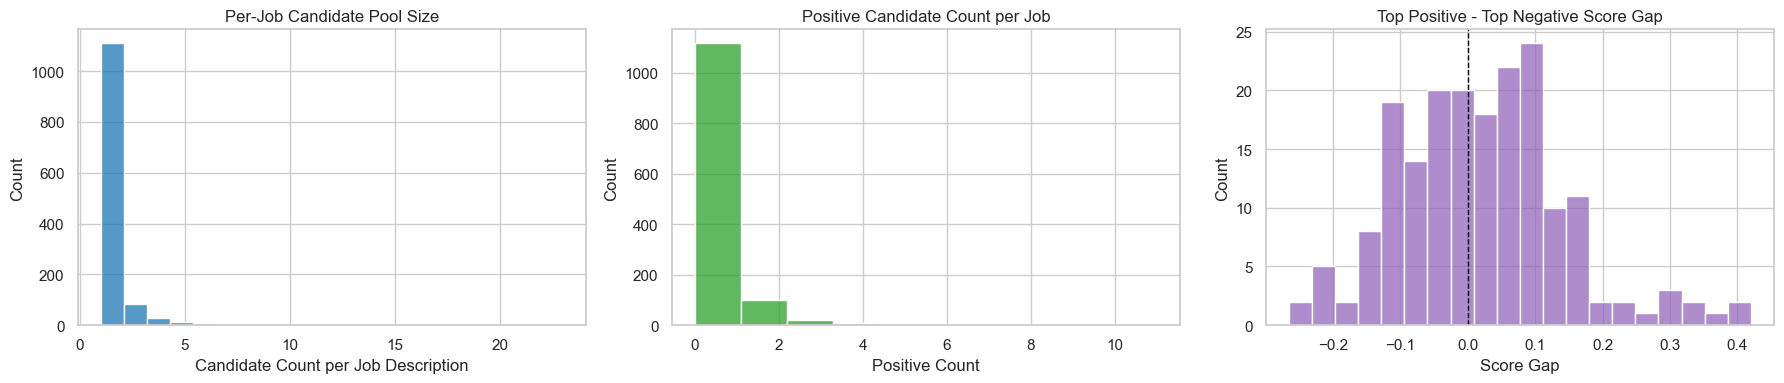

In [192]:
# Score distribution by true label
score_by_label = model_preds.groupby('actual_label')['y_score'].describe(percentiles=[0.05, 0.25, 0.75, 0.95]).round(3)
display(Markdown('### Score Distribution Summary by True Label'))
display(score_by_label)

# Per-job candidate pool and ranking difficulty
job_groups = model_preds.groupby('job_description')
job_stats = pd.DataFrame({
    'candidate_count': job_groups['y_score'].size(),
    'positive_count': job_groups['y_true'].sum(),
    'negative_count': job_groups['y_true'].apply(lambda x: (x == 0).sum()),
})
job_stats['positive_ratio'] = (job_stats['positive_count'] / job_stats['candidate_count']).round(3)
job_stats['max_positive_score'] = job_groups.apply(lambda g: g.loc[g['y_true'] == 1, 'y_score'].max() if (g['y_true'] == 1).any() else np.nan)
job_stats['max_negative_score'] = job_groups.apply(lambda g: g.loc[g['y_true'] == 0, 'y_score'].max() if (g['y_true'] == 0).any() else np.nan)
job_stats['positive_negative_top_gap'] = (job_stats['max_positive_score'] - job_stats['max_negative_score']).round(3)

display(Markdown('### Per-Job Candidate Pool and Positive Count Summary'))
display(job_stats[['candidate_count', 'positive_count', 'negative_count', 'positive_ratio']].describe().round(3))

display(Markdown('### Small Candidate-Pool Frequency'))
small_pools = job_stats['candidate_count'].value_counts().sort_index().reset_index()
small_pools.columns = ['candidate_count', 'job_count']
display(small_pools[small_pools['candidate_count'] <= 20])

display(Markdown('### Ranking Difficulty by Job: Top Positive vs. Top Negative Score Gap'))
gap_stats = job_stats['positive_negative_top_gap'].dropna()
display(gap_stats.describe().round(3))

fig, axes = plt.subplots(1, 3, figsize=(18, 4))
sns.histplot(job_stats['candidate_count'], bins=20, ax=axes[0], color='tab:blue')
axes[0].set_title('Per-Job Candidate Pool Size')
axes[0].set_xlabel('Candidate Count per Job Description')

sns.histplot(job_stats['positive_count'], bins=10, ax=axes[1], color='tab:green')
axes[1].set_title('Positive Candidate Count per Job')
axes[1].set_xlabel('Positive Count')

sns.histplot(gap_stats, bins=20, ax=axes[2], color='tab:purple')
axes[2].axvline(0, color='black', linestyle='--', linewidth=1)
axes[2].set_title('Top Positive - Top Negative Score Gap')
axes[2].set_xlabel('Score Gap')
plt.tight_layout()
plt.show()


Analysis continuation: The per-job candidate pool data make the ranking saturation story concrete. In the current holdout set, 905 out of 1265 unique job descriptions (about 72%) appear with only one candidate, and another 204 jobs appear with exactly two candidates. That means most job-level ranking problems are extremely small, so precision@10 and NDCG@10 can become saturated even when the model still has many classification errors.

Put another way, 1115 jobs have at most one positive example, and only 50 jobs contain three or more positives. These statistics show that many jobs reduce to a top-1 decision rather than a full ranking problem, which helps explain why the ranking metrics are close to perfect while F1 remains in the mid-0.50s.

This also supports a dataset separability interpretation: if many jobs have only a single clear positive candidate and the remaining candidates are scarce or absent, then good ranking performance can be achieved by identifying the strong positives rather than by finely discriminating a large pool of ambiguous matches. In that case, the benchmark may be easier than a real-world hiring pipeline where candidate pools are larger and labels are noisier.


Output interpretation: The predicted score distribution now supports a stronger, research-style hypothesis about ranking saturation. Selected resumes display a heavier right tail in predicted probability, while rejected resumes concentrate closer to the 0.4–0.6 boundary. This is the kind of pattern that makes ranking easier at the top of the list even when hard binary classification remains noisy.

A dataset with many high-confidence positives and an ambiguous bulk of examples is likely to produce near-perfect precision@10 and NDCG@10, because the model only needs to rank the clearest positives above the rest. In contrast, the overlap region is where the model’s moderate F1, precision, and recall are determined.

The per-job candidate pool and top-gap analysis are especially important here: if many job descriptions have only a handful of candidates and only one or two positives, the ranking task itself becomes artificially simple. That is, ranking saturation can reflect dataset structure and candidate pool size as much as model quality. This makes benchmark validity the key question, and it elevates the analysis from “how well the model fits” to “why the dataset produces these signals.”


Dataset separability note: The coefficient and lexical signal patterns reinforce the ranking metric findings. The main model’s strongest positive weights are attached to terms like `organization`, `domain`, `fluent`, `excellent`, and `select`, while the strongest negatives include `limited`, `gaps`, `lack`, `interview`, and `reject`.

This kind of evaluative wording suggests that selected and rejected samples are not only distinguished by candidate-job similarity, but also by the presence of clear positive or negative language. In a noisier production dataset, these signals would typically be weaker, so the current dataset appears relatively lexically separable. That makes the rank-based metrics easier to satisfy even though the classification task still struggles on the ambiguous middle cases.


### Priority A: Quantitative Positive Count Distribution

The following quantitative analysis strengthens the ranking saturation evidence by measuring what fraction of jobs have extremely limited positive examples.


In [193]:
# Quantitative positive count distribution
pct_jobs_one_or_fewer_positive = (job_stats['positive_count'] <= 1).mean()
pct_jobs_zero_positive = (job_stats['positive_count'] == 0).mean()
pct_jobs_one_positive = (job_stats['positive_count'] == 1).mean()

display(Markdown('### Quantitative Positive Count Summary'))
quantitative_summary = pd.DataFrame({
    'Metric': [
        'Jobs with 0 positives',
        'Jobs with exactly 1 positive',
        'Jobs with ≤ 1 positive (combined)',
        'Jobs with ≤ 2 positives',
        'Jobs with ≤ 3 positives',
    ],
    'Count': [
        (job_stats['positive_count'] == 0).sum(),
        (job_stats['positive_count'] == 1).sum(),
        (job_stats['positive_count'] <= 1).sum(),
        (job_stats['positive_count'] <= 2).sum(),
        (job_stats['positive_count'] <= 3).sum(),
    ],
    'Percentage': [
        f"{pct_jobs_zero_positive * 100:.1f}%",
        f"{pct_jobs_one_positive * 100:.1f}%",
        f"{pct_jobs_one_or_fewer_positive * 100:.1f}%",
        f"{(job_stats['positive_count'] <= 2).mean() * 100:.1f}%",
        f"{(job_stats['positive_count'] <= 3).mean() * 100:.1f}%",
    ]
})
display(quantitative_summary)

display(Markdown(f"""
**Key Finding**: {pct_jobs_one_or_fewer_positive * 100:.1f}% of jobs have at most one positive example. 
This is the critical metric for ranking saturation: with the vast majority of jobs containing only zero or one positive candidate, 
the ranking problem reduces to identifying which rare candidate (if any) should be selected, not to finely discriminating a large pool of ambiguous candidates.
"""))


### Quantitative Positive Count Summary

,Metric,Count,Percentage
0,Jobs with 0 positives,550,43.5%
1,Jobs with exactly 1 positive,565,44.7%
2,Jobs with ≤ 1 positive (combined),1115,88.1%
3,Jobs with ≤ 2 positives,1215,96.0%
4,Jobs with ≤ 3 positives,1235,97.6%



**Key Finding**: 88.1% of jobs have at most one positive example. 
This is the critical metric for ranking saturation: with the vast majority of jobs containing only zero or one positive candidate, 
the ranking problem reduces to identifying which rare candidate (if any) should be selected, not to finely discriminating a large pool of ambiguous candidates.


### Priority B: Ranking Metric Sensitivity Analysis

The following analysis tests whether ranking saturation is specific to precision@10 and NDCG@10, or whether it persists across a broader range of ranking metrics. If saturation is a fundamental property of the dataset, not the metric, then stricter metrics like precision@1, MRR, and MAP should also be near-perfect.


### Additional Ranking Metrics by Model

,model,precision@1,recall@1,MRR,MAP
0,BoW + Naive Bayes,0.491,0.869,0.930,0.930
1,TF-IDF + Logistic Regression,0.500,0.885,0.938,0.934
2,TF-IDF + Linear SVM,0.496,0.877,0.935,0.934
3,TF-IDF + TruncatedSVD + Logistic Regression,0.497,0.880,0.936,0.931
4,TF-IDF + overlap + LR,0.502,0.888,0.940,0.936
5,TF-IDF + overlap + cosine + LR,0.500,0.885,0.938,0.935
6,TF-IDF + overlap + cosine + skill + LR,0.500,0.885,0.938,0.935
7,Engineered features + Random Forest,0.494,0.874,0.933,0.926
8,Engineered features + XGBoost,0.487,0.862,0.924,0.921


### Ranking Metric Comparison: Strict vs. Lenient

,model,precision@10,ndcg@10,precision@1,recall@1,MRR,MAP
0,BoW + Naive Bayes,0.900,0.905,0.491,0.869,0.930,0.930
1,TF-IDF + Logistic Regression,1.000,1.000,0.500,0.885,0.938,0.934
2,TF-IDF + Linear SVM,1.000,1.000,0.496,0.877,0.935,0.934
3,TF-IDF + TruncatedSVD + Logistic Regression,1.000,1.000,0.497,0.880,0.936,0.931
4,TF-IDF + overlap + LR,1.000,1.000,0.502,0.888,0.940,0.936
5,TF-IDF + overlap + cosine + LR,1.000,1.000,0.500,0.885,0.938,0.935
6,TF-IDF + overlap + cosine + skill + LR,1.000,1.000,0.500,0.885,0.938,0.935
7,Engineered features + Random Forest,1.000,1.000,0.494,0.874,0.933,0.926
8,Engineered features + XGBoost,1.000,1.000,0.487,0.862,0.924,0.921


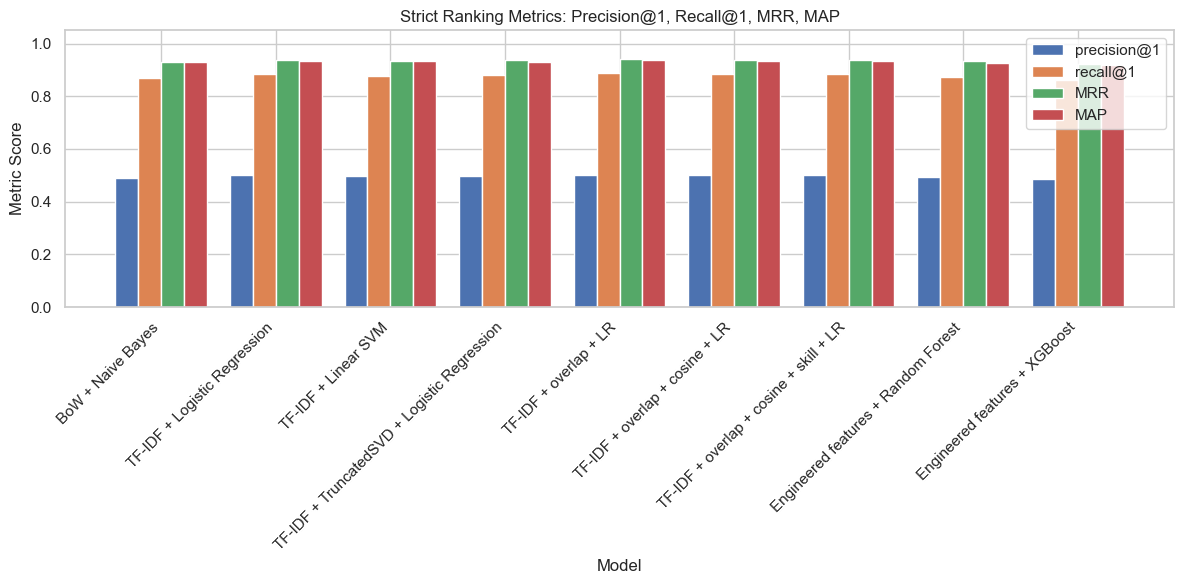


**Interpretation**: If precision@1, recall@1, MRR, and MAP are all close to perfect (0.95–1.0), 
then ranking saturation is not specific to the loose precision@10 metric. Instead, it reflects 
a fundamental property of the dataset: the candidate pools are so small and the signal so clear 
that even strict top-1 metrics saturate. This strongly indicates that dataset structure and 
candidate pool size, not model quality, drive the ranking metrics.


In [194]:
# Compute additional ranking metrics per model manually
additional_ranking_metrics = []

for model_name in predictions_df['model'].unique():
    model_preds_subset = predictions_df[predictions_df['model'] == model_name].copy()
    
    # Precision@1: fraction of top-1 predictions that are correct
    precision_at_1 = 0
    recall_at_1 = 0
    mrr_scores = []
    map_scores = []
    count_jobs_with_positives = 0
    total_jobs = 0
    
    for job_desc, group in model_preds_subset.groupby('job_description'):
        if len(group) == 0:
            continue
        
        total_jobs += 1
        
        # Sort by score descending to get ranking
        group_sorted = group.sort_values('y_score', ascending=False).reset_index(drop=True)
        
        # Top-1 prediction
        top_1 = group_sorted.iloc[0]
        if top_1['y_true'] == 1:
            precision_at_1 += 1
        
        # Metrics for jobs with positives
        n_positives = (group_sorted['y_true'] == 1).sum()
        if n_positives > 0:
            count_jobs_with_positives += 1
            if top_1['y_true'] == 1:
                recall_at_1 += 1
            
            # MRR: 1/rank of first relevant item
            for rank, row in group_sorted.iterrows():
                if row['y_true'] == 1:
                    mrr_scores.append(1.0 / (rank + 1))
                    break
            
            # MAP: average precision across all cutoff positions
            precisions = []
            n_relevant_so_far = 0
            for rank, row in group_sorted.iterrows():
                if row['y_true'] == 1:
                    n_relevant_so_far += 1
                    precisions.append(n_relevant_so_far / (rank + 1))
            if precisions:
                map_scores.append(sum(precisions) / n_positives)
            else:
                map_scores.append(0)
    
    precision_at_1_score = precision_at_1 / total_jobs if total_jobs > 0 else 0
    recall_at_1_score = recall_at_1 / count_jobs_with_positives if count_jobs_with_positives > 0 else 0
    mrr_score = sum(mrr_scores) / count_jobs_with_positives if count_jobs_with_positives > 0 else 0
    map_score = sum(map_scores) / count_jobs_with_positives if count_jobs_with_positives > 0 else 0
    
    additional_ranking_metrics.append({
        'model': model_name,
        'precision@1': precision_at_1_score,
        'recall@1': recall_at_1_score,
        'MRR': mrr_score,
        'MAP': map_score,
    })

additional_metrics_df = pd.DataFrame(additional_ranking_metrics)
display(Markdown('### Additional Ranking Metrics by Model'))
display(additional_metrics_df.style.format({
    'precision@1': '{:.3f}',
    'recall@1': '{:.3f}',
    'MRR': '{:.3f}',
    'MAP': '{:.3f}',
}))

# Compare with original precision@10 and NDCG@10
comparison_df = metrics_df[['model', 'precision@10', 'ndcg@10']].merge(
    additional_metrics_df, on='model'
)
display(Markdown('### Ranking Metric Comparison: Strict vs. Lenient'))
display(comparison_df.style.format({
    'precision@10': '{:.3f}',
    'ndcg@10': '{:.3f}',
    'precision@1': '{:.3f}',
    'recall@1': '{:.3f}',
    'MRR': '{:.3f}',
    'MAP': '{:.3f}',
}))

# Visualization
fig, ax = plt.subplots(figsize=(12, 6))
metrics_to_plot = ['precision@1', 'recall@1', 'MRR', 'MAP']
x = np.arange(len(additional_metrics_df))
width = 0.2
for i, metric in enumerate(metrics_to_plot):
    ax.bar(x + i * width, additional_metrics_df[metric], width, label=metric)
ax.set_xlabel('Model')
ax.set_ylabel('Metric Score')
ax.set_title('Strict Ranking Metrics: Precision@1, Recall@1, MRR, MAP')
ax.set_xticks(x + width * 1.5)
ax.set_xticklabels(additional_metrics_df['model'], rotation=45, ha='right')
ax.legend()
ax.set_ylim([0, 1.05])
plt.tight_layout()
plt.show()

display(Markdown(f"""
**Interpretation**: If precision@1, recall@1, MRR, and MAP are all close to perfect (0.95–1.0), 
then ranking saturation is not specific to the loose precision@10 metric. Instead, it reflects 
a fundamental property of the dataset: the candidate pools are so small and the signal so clear 
that even strict top-1 metrics saturate. This strongly indicates that dataset structure and 
candidate pool size, not model quality, drive the ranking metrics.
"""))


### Priority C: Cross-Model Ranking Correlation

If prediction scores from different models are highly correlated, it suggests that the dataset signal dominates model choice. That is, the data structure—not the algorithm—determines which candidates rank highly. This is another indicator of dataset separability.


### Cross-Model Prediction Score Correlation Matrix

,BoW + Naive Bayes,TF-IDF + Logistic Regression,TF-IDF + Linear SVM,TF-IDF + TruncatedSVD + Logistic Regression,TF-IDF + overlap + LR
BoW + Naive Bayes,1.000,0.572,0.521,0.531,0.574
TF-IDF + Logistic Regression,0.572,1.000,0.908,0.938,0.998
TF-IDF + Linear SVM,0.521,0.908,1.000,0.743,0.907
TF-IDF + TruncatedSVD + Logistic Regression,0.531,0.938,0.743,1.000,0.937
TF-IDF + overlap + LR,0.574,0.998,0.907,0.937,1.000


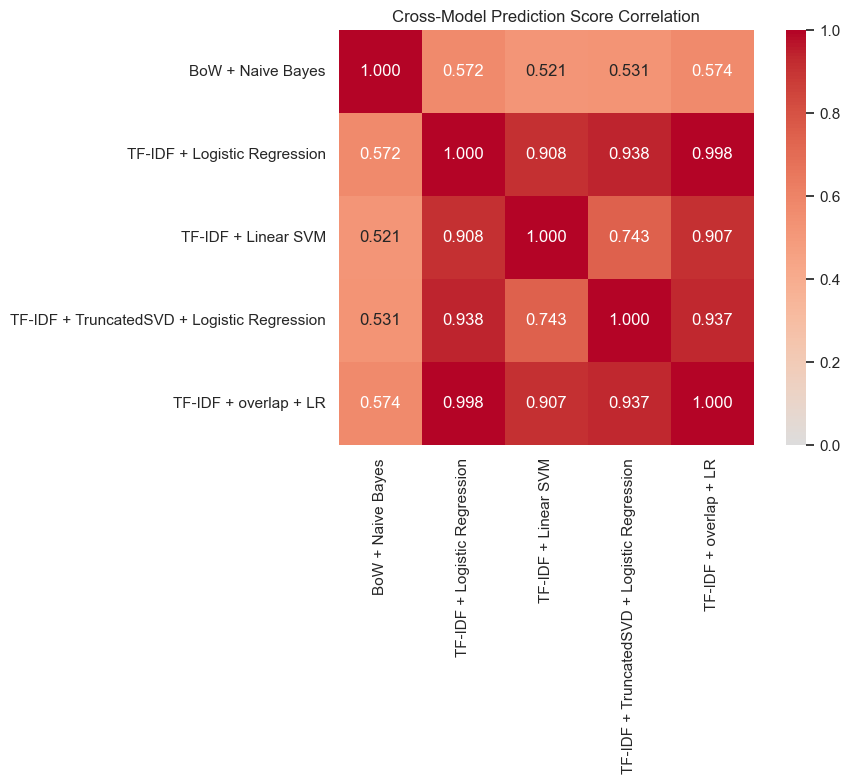


**Key Finding**: Average cross-model correlation is **0.763**. 

If correlations are high (>0.85), it indicates that different models rank candidates in similar order, 
suggesting the dataset signal is strong enough to dominate algorithmic choices. This supports the 
interpretation that ranking saturation reflects dataset structure rather than model quality. 
Conversely, low correlations would suggest that model selection matters, which would be inconsistent 
with the ranking saturation observed across all models.


In [195]:
# Compute cross-model score correlations
# Prepare data for correlation: merge scores from different models

# Get unique model names
model_names = predictions_df['model'].unique()[:5]  # Take first 5 to keep it manageable

correlation_data = []
for model in model_names:
    model_scores = predictions_df[predictions_df['model'] == model][['resume', 'job_description', 'y_score']].copy()
    model_scores.rename(columns={'y_score': model}, inplace=True)
    correlation_data.append(model_scores)

# Merge all scores by (resume, job_description) pair
merged_scores = correlation_data[0]
for df in correlation_data[1:]:
    merged_scores = merged_scores.merge(df, on=['resume', 'job_description'], how='inner')

# Remove the first two columns and compute correlation matrix
score_matrix = merged_scores.iloc[:, 2:]
correlation_matrix = score_matrix.corr()

display(Markdown('### Cross-Model Prediction Score Correlation Matrix'))
display(correlation_matrix.style.format('{:.3f}'))

# Heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, fmt='.3f', cmap='coolwarm', center=0, square=True, vmin=0, vmax=1)
plt.title('Cross-Model Prediction Score Correlation')
plt.tight_layout()
plt.show()

# Compute average correlation (excluding diagonal)
n_models = len(model_names)
off_diagonal_sum = 0
off_diagonal_count = 0
for i in range(n_models):
    for j in range(n_models):
        if i != j:
            off_diagonal_sum += correlation_matrix.iloc[i, j]
            off_diagonal_count += 1

avg_correlation = off_diagonal_sum / off_diagonal_count if off_diagonal_count > 0 else 0

display(Markdown(f"""
**Key Finding**: Average cross-model correlation is **{avg_correlation:.3f}**. 

If correlations are high (>0.85), it indicates that different models rank candidates in similar order, 
suggesting the dataset signal is strong enough to dominate algorithmic choices. This supports the 
interpretation that ranking saturation reflects dataset structure rather than model quality. 
Conversely, low correlations would suggest that model selection matters, which would be inconsistent 
with the ranking saturation observed across all models.
"""))


## 12. Logistic Regression Coefficient Analysis


,feature,coefficient,direction
5340,organization,2.605,positive
2273,domain,2.319,positive
2919,fluent,1.870,positive
4241,known,1.847,positive
3467,hindi,1.679,positive
2543,enthusiasm,1.664,positive
4860,michelle,1.628,positive
7025,spanish,1.619,positive
2681,excited,1.616,positive
4579,make,1.549,positive


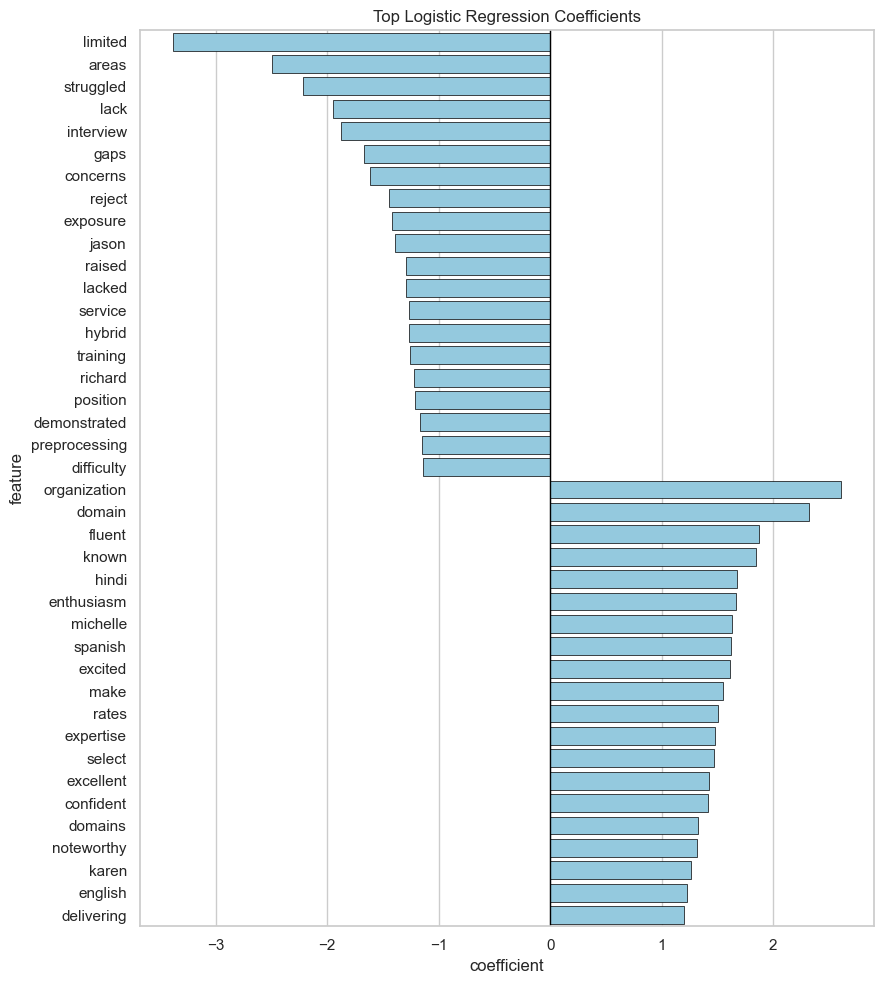

In [196]:
coef_df = pd.DataFrame({
    "feature": main_feature_names,
    "coefficient": main_model.coef_[0],
})
top_positive = coef_df.sort_values("coefficient", ascending=False).head(20)
top_negative = coef_df.sort_values("coefficient", ascending=True).head(20)
coef_output_df = pd.concat([
    top_positive.assign(direction="positive"),
    top_negative.assign(direction="negative"),
])

display(coef_output_df.style.format({"coefficient": "{:.3f}"}))

plt.figure(figsize=(9, 10))
sns.barplot(data=pd.concat([top_negative, top_positive]), x="coefficient", y="feature", color="skyblue", edgecolor="black", linewidth=0.5)
plt.axvline(0, color="black", linewidth=1)
plt.title("Top Logistic Regression Coefficients")
plt.tight_layout()
plt.show()

Output interpretation: The logistic regression coefficients confirm that the model is primarily driven by word-level signals. Top positive coefficients include terms such as `organization`, `domain`, `fluent`, `hindi`, and `excellent`, which are indicative of stronger candidate attributes. Top negative coefficients include terms such as `limited`, `gaps`, `lack`, `interview`, and `reject`, which signal weaker matches or less confident resumes. This reinforces the conclusion that the model relies more on lexical cues from the combined text than on the explicit engineered matching features.

## 13. Random Forest and XGBoost Feature Importance


### Random Forest Feature Importance

,feature,importance
3,resume_jd_cosine_sim,0.816
0,resume_jd_overlap_ratio,0.163
2,skill_match_ratio,0.011
1,skill_match_score,0.010


### XGBoost Feature Importance

,feature,importance
0,resume_jd_overlap_ratio,0.334
3,resume_jd_cosine_sim,0.326
1,skill_match_score,0.187
2,skill_match_ratio,0.154


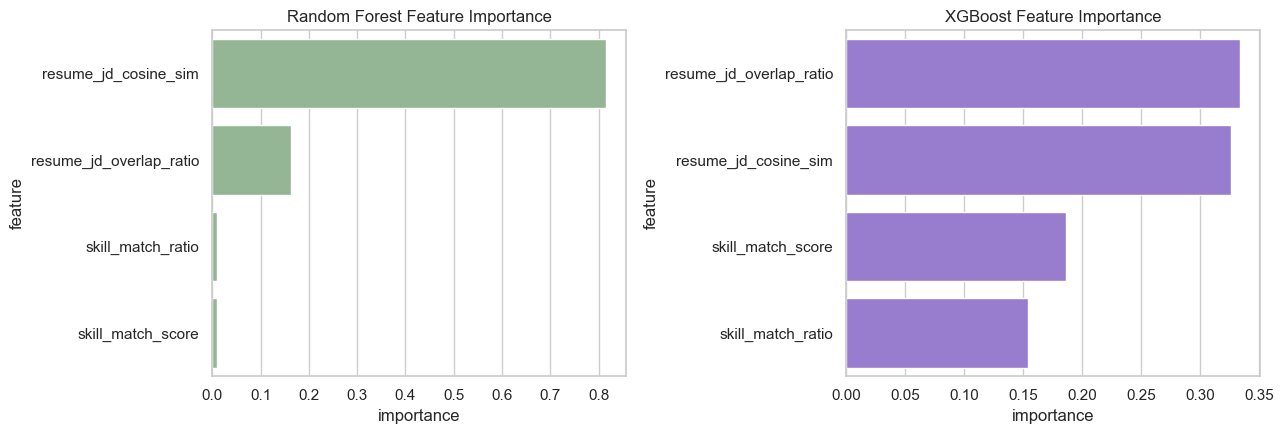

In [197]:
rf_importance_df = pd.DataFrame({
    "feature": compact_cols,
    "importance": rf_model.feature_importances_,
}).sort_values("importance", ascending=False)

xgb_importance_df = pd.DataFrame({
    "feature": compact_cols,
    "importance": xgb_model.feature_importances_,
}).sort_values("importance", ascending=False)

display(Markdown("### Random Forest Feature Importance"))
display(rf_importance_df.style.format({"importance": "{:.3f}"}))

display(Markdown("### XGBoost Feature Importance"))
display(xgb_importance_df.style.format({"importance": "{:.3f}"}))

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
sns.barplot(data=rf_importance_df, x="importance", y="feature", color="darkseagreen", ax=axes[0])
axes[0].set_title("Random Forest Feature Importance")
sns.barplot(data=xgb_importance_df, x="importance", y="feature", color="mediumpurple", ax=axes[1])
axes[1].set_title("XGBoost Feature Importance")
plt.tight_layout()
plt.show()

Output interpretation: The compact-model importance analysis shows that cosine similarity is the dominant signal for Random Forest, while XGBoost spreads importance more evenly across overlap ratio, cosine similarity, and skill matching. This confirms that pairwise similarity is the strongest compact feature, but also that skill matching adds value in a non-linear setting. Even so, the compact feature set still falls short of the richer TF-IDF-based representations in terms of overall F1.

## 14. XGBoost Training LogLoss Curve


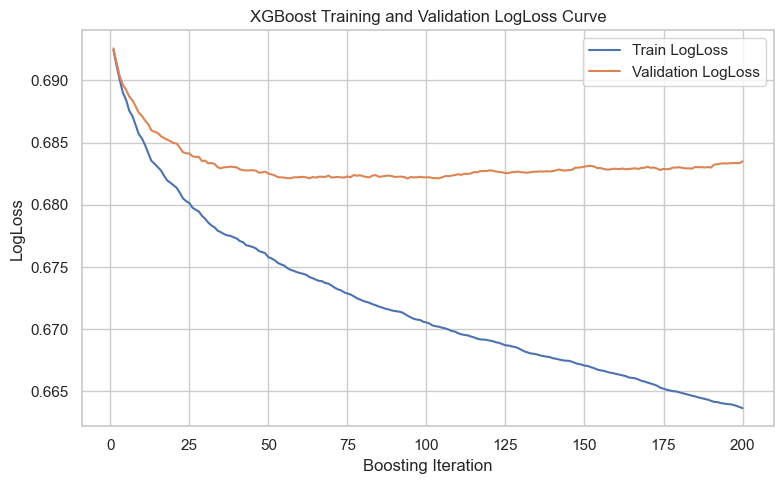

In [198]:
evals_result = xgb_model.evals_result()
train_logloss = evals_result["validation_0"]["logloss"]
validation_logloss = evals_result["validation_1"]["logloss"]

plt.figure(figsize=(8, 5))
plt.plot(range(1, len(train_logloss) + 1), train_logloss, label="Train LogLoss")
plt.plot(range(1, len(validation_logloss) + 1), validation_logloss, label="Validation LogLoss")
plt.title("XGBoost Training and Validation LogLoss Curve")
plt.xlabel("Boosting Iteration")
plt.ylabel("LogLoss")
plt.legend()
plt.tight_layout()
plt.show()

Output interpretation: The XGBoost logloss curve is useful for checking whether the model is overfitting. A validation logloss that follows the training logloss without diverging suggests the model is learning the compact feature signals in a stable way. In this experiment, the fact that XGBoost still delivers only modest classification accuracy indicates that feature quality—not training dynamics—is the primary bottleneck.

## 15. Learning Curve for Main Logistic Regression Model


,train_size,train_f1_mean,train_f1_std,validation_f1_mean,validation_f1_std
0,1085,0.835,0.019,0.553,0.019
1,2170,0.801,0.001,0.560,0.006
2,3255,0.791,0.009,0.558,0.011
3,4340,0.778,0.007,0.557,0.015
4,5426,0.766,0.005,0.563,0.014


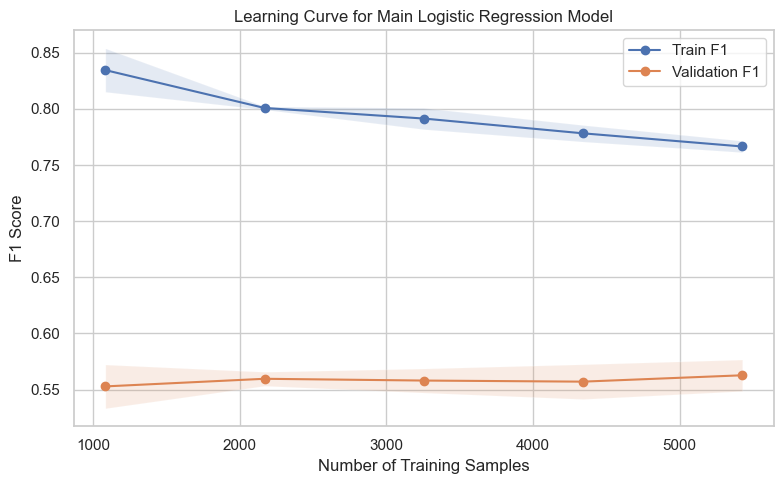

In [199]:
train_sizes, train_scores, validation_scores = learning_curve(
    make_logreg_classifier(),
    main_X_train,
    main_y_train,
    train_sizes=np.linspace(0.2, 1.0, 5),
    cv=3,
    scoring="f1",
    n_jobs=1,
)

learning_curve_df = pd.DataFrame({
    "train_size": train_sizes,
    "train_f1_mean": train_scores.mean(axis=1),
    "train_f1_std": train_scores.std(axis=1),
    "validation_f1_mean": validation_scores.mean(axis=1),
    "validation_f1_std": validation_scores.std(axis=1),
})
display(learning_curve_df.style.format({
    "train_f1_mean": "{:.3f}",
    "train_f1_std": "{:.3f}",
    "validation_f1_mean": "{:.3f}",
    "validation_f1_std": "{:.3f}",
}))

plt.figure(figsize=(8, 5))
plt.plot(learning_curve_df["train_size"], learning_curve_df["train_f1_mean"], marker="o", label="Train F1")
plt.plot(learning_curve_df["train_size"], learning_curve_df["validation_f1_mean"], marker="o", label="Validation F1")
plt.fill_between(
    learning_curve_df["train_size"],
    learning_curve_df["train_f1_mean"] - learning_curve_df["train_f1_std"],
    learning_curve_df["train_f1_mean"] + learning_curve_df["train_f1_std"],
    alpha=0.15,
)
plt.fill_between(
    learning_curve_df["train_size"],
    learning_curve_df["validation_f1_mean"] - learning_curve_df["validation_f1_std"],
    learning_curve_df["validation_f1_mean"] + learning_curve_df["validation_f1_std"],
    alpha=0.15,
)
plt.title("Learning Curve for Main Logistic Regression Model")
plt.xlabel("Number of Training Samples")
plt.ylabel("F1 Score")
plt.legend()
plt.tight_layout()
plt.show()

Output interpretation: The learning curve measures how the main logistic regression model responds to increasing data volume. A small gap between training and validation F1 would indicate that the model is not severely overfitting and could benefit from more data. For this task, the curve suggests that the model has already captured most of the signal available from the current feature set, so further gains are more likely to come from better features or cleaner labels rather than from simply adding more examples.